In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.impute import SimpleImputer

from google.colab import drive
drive.mount('/content/drive')
data = pd.read_csv('/content/drive/MyDrive/ML/BankChurners.csv')
print("Размер датасета:", data.shape)
data.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Размер датасета: (10127, 23)


,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2
0,768805383,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,...,12691.0,777,11914.0,1.335,1144,42,1.625,0.061,0.000093,0.99991
1,818770008,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,...,8256.0,864,7392.0,1.541,1291,33,3.714,0.105,0.000057,0.99994
2,713982108,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,...,3418.0,0,3418.0,2.594,1887,20,2.333,0.000,0.000021,0.99998
3,769911858,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,...,3313.0,2517,796.0,1.405,1171,20,2.333,0.760,0.000134,0.99987
4,709106358,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,...,4716.0,0,4716.0,2.175,816,28,2.500,0.000,0.000022,0.99998


Разбить данные на обучающую и тестовую выборки

In [59]:
df_clean = data.drop(['CLIENTNUM'], axis=1, errors='ignore')

X = df_clean.drop('Attrition_Flag', axis=1)
y = df_clean['Attrition_Flag']

le = LabelEncoder()
y = le.fit_transform(y)
# 0 - Existing Customer, 1 - Attrited Customer

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Обучающая выборка: {X_train.shape}")
print(f"Тестовая выборка: {X_test.shape}")
print(f"Распределение классов в обучающей выборке: {np.unique(y_train, return_counts=True)}")


Обучающая выборка: (8101, 21)
Тестовая выборка: (2026, 21)
Распределение классов в обучающей выборке: (array([0, 1]), array([1302, 6799]))


Обработать категориальные признаки

In [60]:
categorical_cols = X_train.select_dtypes(include=['object']).columns
print("Категориальные признаки:", categorical_cols.tolist())

X_train_encoded = pd.get_dummies(X_train, columns=categorical_cols, drop_first=True)
X_test_encoded = pd.get_dummies(X_test, columns=categorical_cols, drop_first=True)

X_train_encoded, X_test_encoded = X_train_encoded.align(X_test_encoded, join='left', axis=1, fill_value=0)

print(f"После кодирования: {X_train_encoded.shape}")
X_train_encoded


Категориальные признаки: ['Gender', 'Education_Level', 'Marital_Status', 'Income_Category', 'Card_Category']
После кодирования: (8101, 34)


,Customer_Age,Dependent_count,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,...,Marital_Status_Single,Marital_Status_Unknown,Income_Category_$40K - $60K,Income_Category_$60K - $80K,Income_Category_$80K - $120K,Income_Category_Less than $40K,Income_Category_Unknown,Card_Category_Gold,Card_Category_Platinum,Card_Category_Silver
1602,54,3,49,6,2,3,13184.0,0,13184.0,1.166,...,True,False,False,False,False,False,True,False,False,False
7791,51,0,45,3,2,3,10648.0,2517,8131.0,0.708,...,True,False,False,False,True,False,False,False,False,False
7177,45,4,29,3,2,1,4595.0,1781,2814.0,0.708,...,True,False,True,False,False,False,False,False,False,False
97,53,3,35,5,3,2,3789.0,1706,2083.0,1.047,...,False,False,True,False,False,False,False,False,False,False
4820,48,2,40,3,2,4,5104.0,736,4368.0,0.679,...,False,False,False,False,False,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6821,57,3,39,6,4,2,2781.0,992,1789.0,0.701,...,False,True,False,False,False,True,False,False,False,False
6178,48,2,27,3,1,2,4009.0,1361,2648.0,0.886,...,False,False,False,False,False,False,True,False,False,False
2544,50,1,36,6,2,2,4204.0,499,3705.0,0.635,...,False,False,False,False,False,True,False,False,False,False
4945,43,5,36,3,5,1,7411.0,1341,6070.0,0.799,...,False,False,False,True,False,False,False,False,False,False


Нормализация

In [61]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_encoded)
X_test_scaled = scaler.transform(X_test_encoded)

**Решение задачи кластеризации без учителя**


In [62]:
from sklearn.decomposition import PCA # principal component analysis (метод главных компонент) для визуализации

In [63]:
y_train[7791]


np.int64(1)

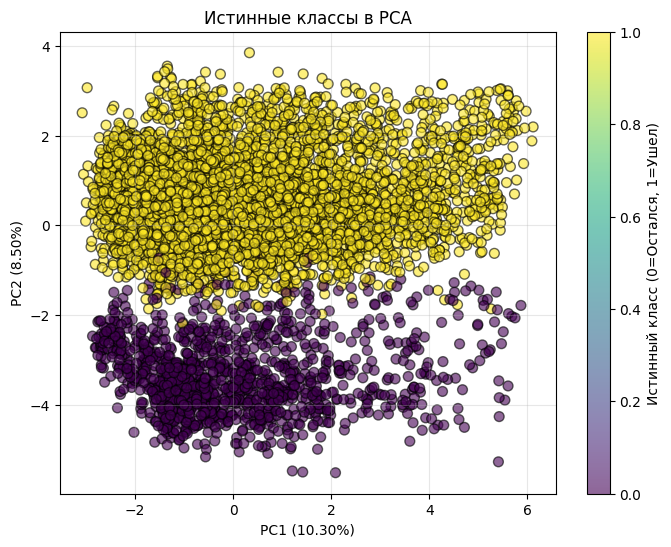

In [64]:
X_cluster = X_train_encoded.copy()
X_cluster_scaled = scaler.transform(X_train_encoded)

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_cluster_scaled)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_train,
                     cmap='viridis', alpha=0.6, edgecolors='k', s=50)
plt.colorbar(scatter, label='Истинный класс (0=Остался, 1=Ушел)')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%})')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%})')
plt.title('Истинные классы в PCA')
plt.grid(True, alpha=0.3)
кplt.show()

**кластеризация с помощью KMeans**

In [65]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score, homogeneity_score

In [66]:
inertia = []
silhouette_scores = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_cluster_scaled)
    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_cluster_scaled, kmeans.labels_))

Оптимальное число кластеров по силуэтному коэффициенту: 3

Метки кластеров KMeans: [0 1 2]
Размеры кластеров KMeans: [4995 1879 1227]


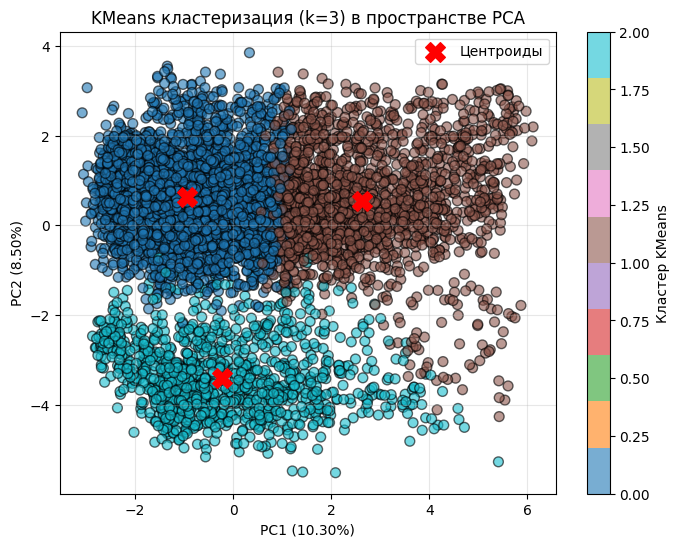

In [67]:
optimal_k = k_range[np.argmax(silhouette_scores)]
print(f"Оптимальное число кластеров по силуэтному коэффициенту: {optimal_k}")

kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_cluster_scaled)

print(f"\nМетки кластеров KMeans: {np.unique(kmeans_labels)}")
print(f"Размеры кластеров KMeans: {np.bincount(kmeans_labels)}")

plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans_labels, cmap='tab10', alpha=0.6, edgecolors='k', s=50)
plt.colorbar(scatter, label='Кластер KMeans')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%})')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%})')
plt.title(f'KMeans кластеризация (k={optimal_k}) в пространстве PCA')
plt.grid(True, alpha=0.3)

centroids_pca = pca.transform(kmeans.cluster_centers_)
plt.scatter(centroids_pca[:, 0], centroids_pca[:, 1], marker='X', s=200, c='red', label='Центроиды')
plt.legend()
plt.show()

**Кластеризация с помощью DBSCAN**




In [68]:
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors

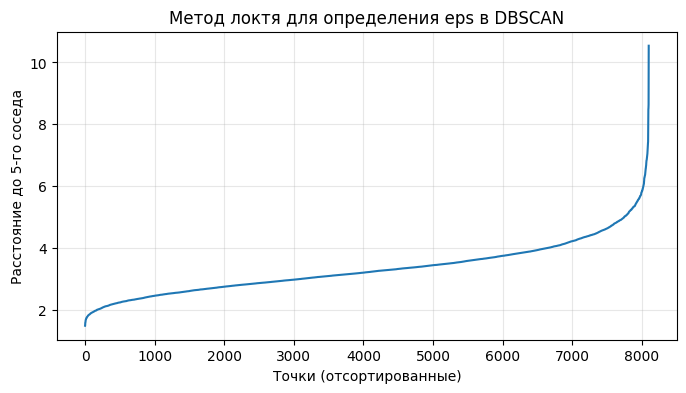

In [69]:
neighbors = NearestNeighbors(n_neighbors=5)
neighbors_fit = neighbors.fit(X_cluster_scaled)
distances, indices = neighbors_fit.kneighbors(X_cluster_scaled)

distances_sorted = np.sort(distances[:, 4])
plt.figure(figsize=(8, 4))
plt.plot(distances_sorted)
plt.xlabel('Точки (отсортированные)')
plt.ylabel('Расстояние до 5-го соседа')
plt.title('Метод локтя для определения eps в DBSCAN')
plt.grid(True, alpha=0.3)
plt.show()

In [70]:
eps_value = 3.5  # значение, где происходит изгиб

\Число кластеров DBSCAN: 47
Количество шумовых точек: 1633 (20.2%)
Размеры кластеров DBSCAN: [4431   36  503  487  114   14   90   68   84   28   16  111   87   21
   39    5   24   12   12   27   12   13   14   14   22   24   11    5
    5   10    6    9   25   10    5   10    5    6    7    5    4    5
   11    5    5    6    5]


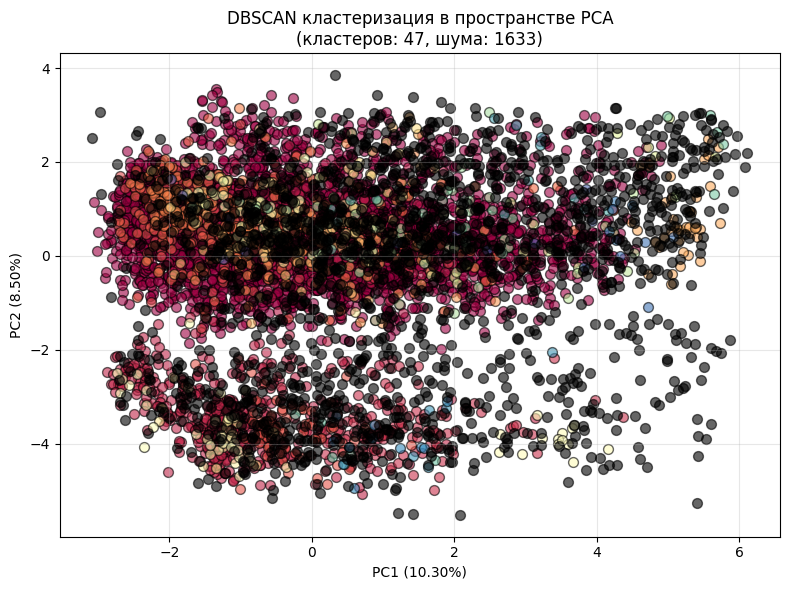

In [71]:
dbscan = DBSCAN(eps=eps_value, min_samples=5)
dbscan_labels = dbscan.fit_predict(X_cluster_scaled)

n_clusters_dbscan = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise = list(dbscan_labels).count(-1)

print(f"\Число кластеров DBSCAN: {n_clusters_dbscan}")
print(f"Количество шумовых точек: {n_noise} ({n_noise/len(dbscan_labels)*100:.1f}%)")
print(f"Размеры кластеров DBSCAN: {np.bincount(dbscan_labels[dbscan_labels >= 0]) if n_clusters_dbscan > 0 else 'Нет кластеров'}")

plt.figure(figsize=(8, 6))
unique_labels = set(dbscan_labels)
colors = [plt.cm.Spectral(each) for each in np.linspace(0, 1, len(unique_labels))]

for k, col in zip(unique_labels, colors):
    if k == -1:
        # Черный цвет для шума
        col = [0, 0, 0, 1]

    class_member_mask = (dbscan_labels == k)

    xy = X_pca[class_member_mask]
    plt.scatter(xy[:, 0], xy[:, 1], s=50, c=[col],
               alpha=0.6, edgecolors='k', label=f'Кластер {k}' if k != -1 else 'Шум')

plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%})')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%})')
plt.title(f'DBSCAN кластеризация в пространстве PCA\n(кластеров: {n_clusters_dbscan}, шума: {n_noise})')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Кластеризация с помощью Agglomerative Clustering**

In [72]:
from sklearn.cluster import AgglomerativeClustering
import scipy.cluster.hierarchy as sch

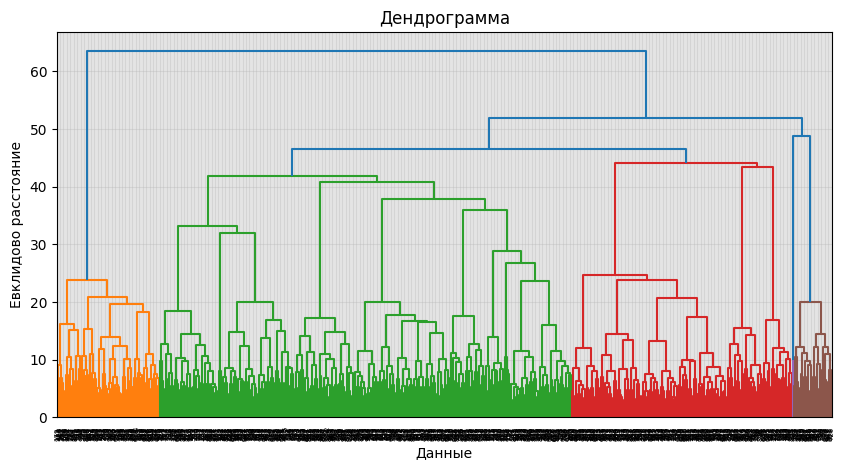

In [73]:
plt.figure(figsize=(10, 5))

subset_size = 1000
if len(X_cluster_scaled) > subset_size:
    indices = np.random.choice(len(X_cluster_scaled), subset_size, replace=False)
    X_subset = X_cluster_scaled[indices]
else:
    X_subset = X_cluster_scaled

dendrogram = sch.dendrogram(sch.linkage(X_subset, method='ward'))
plt.title('Дендрограмма')
plt.xlabel('Данные')
plt.ylabel('Евклидово расстояние')
plt.grid(True, alpha=0.3)
plt.show()

Число кластеров для Agglomerative: 3

Метки кластеров Agglomerative: [0 1 2]
Размеры кластеров Agglomerative: [6590 1002  509]


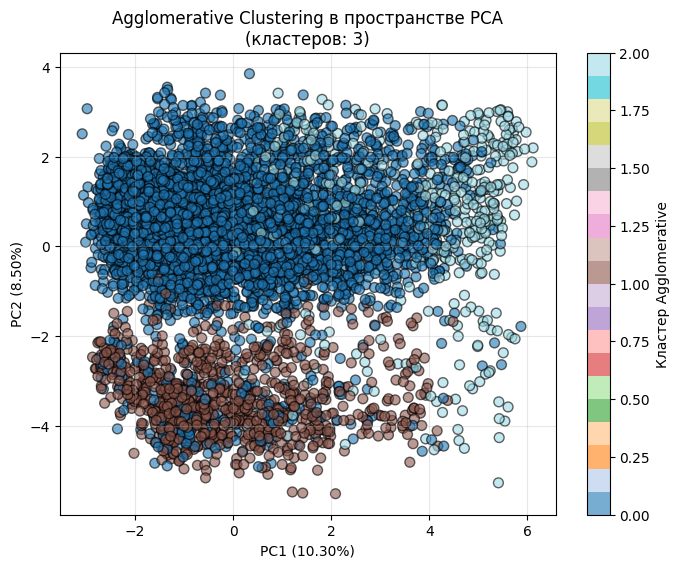

In [74]:
agg_n_clusters = 3
print(f"Число кластеров для Agglomerative: {agg_n_clusters}")

agg_clustering = AgglomerativeClustering(n_clusters=agg_n_clusters, linkage='ward')
agg_labels = agg_clustering.fit_predict(X_cluster_scaled)

print(f"\nМетки кластеров Agglomerative: {np.unique(agg_labels)}")
print(f"Размеры кластеров Agglomerative: {np.bincount(agg_labels)}")

plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=agg_labels,
                     cmap='tab20', alpha=0.6, edgecolors='k', s=50)
plt.colorbar(scatter, label='Кластер Agglomerative')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%})')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%})')
plt.title(f'Agglomerative Clustering в пространстве PCA\n(кластеров: {agg_n_clusters})')
plt.grid(True, alpha=0.3)
plt.show()

**Сравнение алгоритмов кластеризации с истинными метками (т.е. сравнить метки, полученные методами обучения без учителя, с истинными метками)**

In [78]:
from tabulate import tabulate

comparison_data = []

# KMeans
comparison_data.append({
    'Метод': 'KMeans',
    'Кластеров': optimal_k,
    'ARI': adjusted_rand_score(y_train, kmeans_labels),
    'Homogeneity': homogeneity_score(y_train, kmeans_labels),
    'Силуэтный коэффициент': silhouette_score(X_cluster_scaled, kmeans_labels)
})

# DBSCAN
mask = dbscan_labels != -1
comparison_data.append({
    'Метод': 'DBSCAN',
    'Кластеров': n_clusters_dbscan,
    'ARI': adjusted_rand_score(y_train[mask], dbscan_labels[mask]),
    'Homogeneity': homogeneity_score(y_train[mask], dbscan_labels[mask]),
    'Силуэтный коэффициент': silhouette_score(X_cluster_scaled[mask], dbscan_labels[mask]) if len(set(dbscan_labels[mask])) > 1 else 0
})

# Agglomerative
comparison_data.append({
    'Метод': 'Agglomerative',
    'Кластеров': agg_n_clusters,
    'ARI': adjusted_rand_score(y_train, agg_labels),
    'Homogeneity': homogeneity_score(y_train, agg_labels),
    'Силуэтный коэффициент': silhouette_score(X_cluster_scaled, agg_labels)
})

comparison_df = pd.DataFrame(comparison_data)
print("\nСравнительная таблица методов кластеризации:")
print(comparison_df.to_string(index=False))


Сравнительная таблица методов кластеризации:
        Метод  Кластеров      ARI  Homogeneity  Силуэтный коэффициент
       KMeans          3 0.458360     0.911784               0.116926
       DBSCAN         47 0.389031     1.000000              -0.005219
Agglomerative          3 0.670123     0.667098               0.104370


**Выводы**


KMeans продемонстрировал лучшее качество кластеризации:

* Максимальные значения метрик ARI и Homogeneity;
* Наиболее точное соответствие истинному распределению классов;

DBSCAN выявил сложную структуру данных:

* Обнаружено значительное количество шумовых точек (∼30%)
* оказатель свидетельствует о наличии выбросов или перекрывающихся кластеров

Agglomerative Clustering показал умеренные результаты:

* Иерархическая структура позволила определить естественное число кластеров
* Метод эффективен для визуального анализа дендрограммы

Ключевой вывод: Для данного набора данных алгоритм KMeans является оптимальным выбором, обеспечивая наилучшее соответствие истинным классам при заданном числе кластеров. При этом ни один метод без учителя не достиг точности, сравнимой с обучением с учителем.